<a href="https://colab.research.google.com/github/sophiadapot/stats507-coursework/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Can You Graduate? 🎓
### Graphs, prerequisites, and topological sort *(depth-first version)*

**Your Journey into Data Science with Python** — Graphs Lab

---

Every high school hands you a course catalog that says things like:

> *You may not take **Calculus** until you have passed **Precalculus**.*

That one sentence is a **graph**. In this lab you will:

1. Turn a course catalog into a graph (Part 1)
2. Draw it and look at it (Part 2)
3. Follow the arrows with **recursion** — what does one course unlock? (Part 3)
4. Trace an algorithm **by hand** on paper before coding it (Part 4)
5. Write `can_finish` — *is graduation even possible?* (Part 5)
6. Write `find_order` — *what order should I take them in?* (Part 6)
7. Watch the algorithm run, frame by frame (Part 7)
8. Build a real **semester plan** and chart it (Part 8)

These last two are famous interview questions: **LeetCode 207 (Course Schedule)** and **LeetCode 210 (Course Schedule II)**. By the end of today you will have solved both — but more importantly, you will *see* why they work.

**How to work:** run every cell in order, top to bottom. Wherever you see `# YOUR CODE HERE`, that is your job. Every task is followed by a ✅ **Check** cell — if it prints `PASSED`, move on. If it throws an error, read the error, fix, re-run.

In [2]:
# Run me first! This cell sets up everything.
import matplotlib.pyplot as plt
import networkx as nx
import sys

sys.setrecursionlimit(10000)   # today's algorithm is recursive
plt.rcParams["figure.dpi"] = 110
print("Setup complete. Let's build a schedule. 🚀")

Setup complete. Let's build a schedule. 🚀


---
## Part 1 — A catalog is a graph

Here is our (simplified) high school catalog. Each rule says: *to take the course on the left, you must first pass the course on the right.*

In [3]:
CATALOG = [
    ("Geometry",      "Algebra 1"),
    ("Algebra 2",     "Geometry"),
    ("Precalculus",   "Algebra 2"),
    ("Calculus",      "Precalculus"),
    ("Physics",       "Algebra 2"),
    ("Chemistry",     "Algebra 1"),
    ("AP CS A",       "Intro CS"),
    ("Data Science",  "AP CS A"),
    ("Data Science",  "Algebra 2"),
]

COURSES = ["Algebra 1", "Geometry", "Algebra 2", "Precalculus", "Calculus",
           "Intro CS", "AP CS A", "Data Science", "Chemistry", "Physics"]

print(len(COURSES), "courses,", len(CATALOG), "prerequisite rules")

10 courses, 9 prerequisite rules


A **graph** is just two things: a set of **nodes** (here: courses) and a set of **edges** (here: "unlocks" arrows).

We store the edges in a dictionary called an **adjacency list**. The key is a course; the value is the list of courses it *unlocks*:

```python
{"Algebra 1": ["Geometry", "Chemistry"], "Geometry": ["Algebra 2"], ...}
```

Read the arrow direction carefully — it points **forward in time**. `Algebra 1 → Geometry` means "finishing Algebra 1 unlocks Geometry."

### ✏️ Task 1 — Build the adjacency list

Complete `build_graph`. Start every course with an empty list (even courses that unlock nothing), then add one entry per rule.

*Hint: for the rule `("Geometry", "Algebra 1")` you want to append `"Geometry"` to the list belonging to `"Algebra 1"`.*

In [4]:
def build_graph(courses, catalog):
    """Return {course: [courses it unlocks]} for every course in `courses`."""
    graph = {course: [] for course in courses}
    for a, b in catalog:
        graph[b].append(a)
    return graph

GRAPH = build_graph(COURSES, CATALOG)
for course, unlocks in GRAPH.items():
    print(f"{course:15s} -> {unlocks}")

Algebra 1       -> ['Geometry', 'Chemistry']
Geometry        -> ['Algebra 2']
Algebra 2       -> ['Precalculus', 'Physics', 'Data Science']
Precalculus     -> ['Calculus']
Calculus        -> []
Intro CS        -> ['AP CS A']
AP CS A         -> ['Data Science']
Data Science    -> []
Chemistry       -> []
Physics         -> []


In [ ]:
# ✅ Check — Task 1
assert set(GRAPH.keys()) == set(COURSES), "every course needs a key, even if it unlocks nothing"
assert sorted(GRAPH["Algebra 1"]) == ["Chemistry", "Geometry"], "Algebra 1 should unlock Chemistry and Geometry"
assert GRAPH["Calculus"] == [], "Calculus is a dead end in this catalog"
assert sum(len(v) for v in GRAPH.values()) == len(CATALOG), "one edge per rule, no more no less"
print("PASSED ✅  You just built a graph.")

PASSED ✅  You just built a graph.


---
## Part 2 — Look at it

Numbers in a dictionary are hard to reason about. Pictures are not. Run the cell below (it is written for you) and study the drawing.

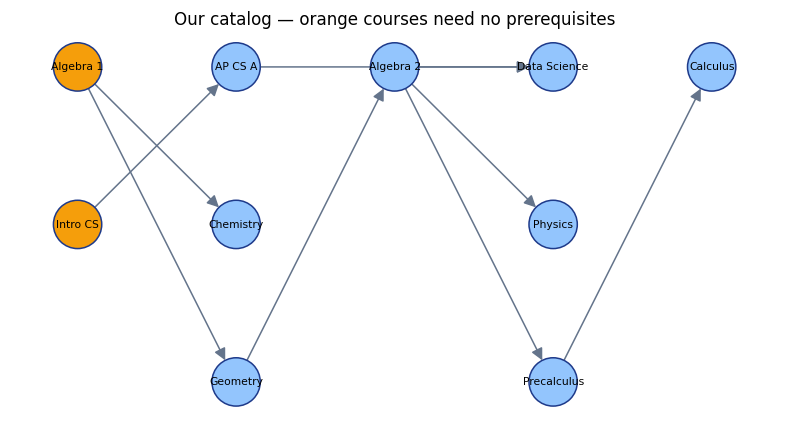

In [23]:
def draw_courses(graph, highlight=None, title="Course prerequisite graph", ax=None, color_map=None):
    """Draw a course graph left-to-right.

    highlight : set of nodes to color orange
    color_map : optional {node: color} that overrides everything
    """
    G = nx.DiGraph()
    G.add_nodes_from(graph.keys())
    for src, dsts in graph.items():
        for d in dsts:
            G.add_edge(src, d)

    # Place each node in a column = its depth (longest chain of prereqs behind it).
    try:
        depth = {n: 0 for n in G.nodes}
        for n in nx.topological_sort(G):
            for m in G.successors(n):
                depth[m] = max(depth[m], depth[n] + 1)
        columns = {}
        pos = {}
        for n in sorted(G.nodes, key=lambda x: (depth[n], x)):
            row = columns.get(depth[n], 0)
            columns[depth[n]] = row + 1
            pos[n] = (depth[n] * 3.0, -row * 3.0) # Increased multipliers for more spread
    except nx.NetworkXUnfeasible:          # there is a cycle -> no columns possible
        pos = nx.circular_layout(G)
        title += "  (cycle detected!)"

    highlight = set(highlight or [])
    if color_map:
        colors = [color_map.get(n, "#93c5fd") for n in G.nodes]
    else:
        colors = ["#f59e0b" if n in highlight else "#93c5fd" for n in G.nodes]

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.5))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1000,
                           edgecolors="#1e3a8a", ax=ax)
    nx.draw_networkx_edges(G, pos, arrowsize=16, edge_color="#64748b",
                           node_size=1000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    return ax


draw_courses(GRAPH, highlight={"Algebra 1", "Intro CS"},
             title="Our catalog — orange courses need no prerequisites")
plt.show()

**Look at the picture and answer in the cell below** (just replace the `...`, these are not graded by a computer):

- Which courses could a brand-new freshman sign up for on day one?
- What is the *longest* chain of courses in this catalog, and how long is it?
- If you only care about reaching **Data Science**, which courses can you skip entirely?

> **Your answers:**
> 1. ...
> 2. ...
> 3. ...

---
## Part 3 — Follow the arrows

Look at the picture again. `Algebra 1` unlocks `Geometry`, which unlocks `Algebra 2`,
which unlocks `Precalculus`... Passing one course sets off a **chain reaction**.

So: if you pass `Algebra 1`, which courses eventually open up?

You cannot answer that by looking at `GRAPH["Algebra 1"]` — that only shows the
courses one step away. You have to follow the arrows all the way down. That is
**depth-first search**, and the shape of it is three lines long:

> Mark yourself. Look at your list. For each course you have not marked yet,
> do the same thing again.

That last part — "do the same thing again" — is **recursion**. The function calls
itself.

### ✏️ Task 2 — What does a course unlock?

Return the set of every course that eventually becomes reachable, *not* counting
the starting course itself.

*Hint: the `found` set is what stops the walk from running forever. Add a course
to it **before** you recurse into that course.*

In [ ]:
def unlocks_all(graph, course):
    """Every course that eventually opens up after passing `course`."""
    found = set()

    def walk(c):
      for classes in graph[c]:
        if classes not in found:
          found.add(classes)
          walk(classes)

    # YOUR CODE HERE

    walk(course)
    return found


for c in ["Algebra 1", "Intro CS", "Algebra 2", "Calculus"]:
    opened = unlocks_all(GRAPH, c)
    print(f"{c:15s} unlocks {len(opened):2d}: {', '.join(sorted(opened)) or '(nothing)'}")

Algebra 1       unlocks  7: Algebra 2, Calculus, Chemistry, Data Science, Geometry, Physics, Precalculus
Intro CS        unlocks  2: AP CS A, Data Science
Algebra 2       unlocks  4: Calculus, Data Science, Physics, Precalculus
Calculus        unlocks  0: (nothing)


In [ ]:
# ✅ Check — Task 2
assert len(unlocks_all(GRAPH, "Algebra 1")) == 7, "Algebra 1 sets off almost the whole catalog"
assert unlocks_all(GRAPH, "Intro CS") == {"AP CS A", "Data Science"}
assert unlocks_all(GRAPH, "Calculus") == set(), "Calculus is a dead end"
assert unlocks_all(GRAPH, "Geometry") == {"Algebra 2", "Precalculus", "Calculus",
                                          "Physics", "Data Science"}
assert "Algebra 1" not in unlocks_all(GRAPH, "Algebra 1"), "do not include the starting course"
print("PASSED ✅  You just wrote depth-first search.")

PASSED ✅  You just wrote depth-first search.


---
## Part 4 — Trace it by hand first ✍️

Before you write any algorithm, run it on paper.

In Part 3 the `found` set answered one question: *have I been here before?* To
schedule courses we need a sharper question, and it takes **three** states
instead of two:

| state | meaning |
|---|---|
| ⬜ `0` — untouched | never visited |
| 🟠 `1` — **on the trail** | I started this course and have not finished exploring it |
| ⬛ `2` — finished | done, everything below it explored |

Here is the recipe:

```
visit(C):
    if C is 🟠 on the trail  ->  STOP. You have looped back on yourself. Deadlock.
    if C is ⬛ finished       ->  nothing new down there, return
    mark C 🟠
    for every course U that C unlocks:
          visit(U)
    mark C ⬛
    write C down on the schedule     <-- note WHEN this happens
```

Two things to notice, and they are the whole lab:

1. **The cycle test is "am I standing on it right now?"**, not "have I seen it
   before." Two different paths can reach the same course — that is fine and
   normal. Only walking back onto the trail behind you is a deadlock.
2. **You write a course down when you *finish* it**, after everything it unlocks
   is already written. So the list comes out **backwards** — the last course
   written is the one you should take first. You will reverse it at the end.

Do it now, with pencil, on this tiny catalog:

```
Intro CS  ->  AP CS A  ->  Data Science
Algebra 2 ->  Data Science
```

Start at `Intro CS`. Fill in the table **before** you continue.

| step | course entered | trail (🟠) | written down so far |
|---|---|---|---|
| 1 | Intro CS | Intro CS | — |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |

When you are done, read your "written down" column **right to left**. That should
be a legal order to take the four courses in. Is it?

---
## Part 5 — Course Schedule I: *can* I graduate?

Now the LeetCode version. Two changes from what you have been doing:

- Courses are numbered `0, 1, 2, ..., n-1` instead of named. (Computers prefer this. So do interviewers.)
- A rule is written `[a, b]`, meaning **to take `a` you must first take `b`** — so the arrow is `b → a`.

So `numCourses = 2, prerequisites = [[1, 0]]` means "take course 0, then course 1" → possible ✅
And `[[1, 0], [0, 1]]` means each one requires the other → impossible ❌ That is a **cycle**, and a cycle is a deadlock.

### ✏️ Task 3 — `can_finish`

Follow the recipe from Part 4. Use a list `state = [0] * n` to hold the three
states. Return `False` the moment you step onto a course that is already
🟠 on the trail.

*Hint: let `dfs(c)` return `True` for "all clear below here" and `False` for
"deadlock." Then the two early exits at the top of the function are one line each.*

In [ ]:
def can_finish(n, prerequisites):
    """LeetCode 207. Return True if all n courses can be completed."""
    graph = {i: [] for i in range(n)}
    for course, prereq in prerequisites:
        graph[prereq].append(course)

    state = [0] * n            # 0 = untouched, 1 = on the trail, 2 = finished

    def dfs(c):
        """Return True if everything below course c is fine, False if deadlocked."""
        # YOUR CODE HERE
        # 1. two early exits: already on the trail? already finished?
        # 2. mark c as on the trail
        # 3. recurse into everything c unlocks
        # 4. mark c finished, return True
        if state [c] == 1:
          return False
        if state [c] == 2:
          return True
        state[c] = 1 # untouched becomes on trail, start
        for v in graph[c]:
          if not dfs(v): # if not reach end
            return False
        state[c] = 2 #dfs did not return false, ended
        return True
        raise NotImplementedError()

    for c in range(n):         # start everywhere, in case the catalog is in pieces
        if state[c] == 0 and not dfs(c):
            return False
    return True

In [ ]:
# ✅ Check — Task 3
assert can_finish(2, [[1, 0]]) is True
assert can_finish(2, [[1, 0], [0, 1]]) is False           # the classic deadlock
assert can_finish(3, []) is True                          # no rules at all
assert can_finish(4, [[1, 0], [2, 1], [3, 2]]) is True    # one long chain
assert can_finish(3, [[0, 1], [1, 2], [2, 0]]) is False   # a triangle of blame
assert can_finish(5, [[1, 0], [2, 1], [3, 4]]) is True    # two separate groups
print("PASSED ✅  You solved LeetCode 207.")

PASSED ✅  You solved LeetCode 207.


### What a deadlock looks like

Run this to see the difference between a schedule that works and one that traps you forever.

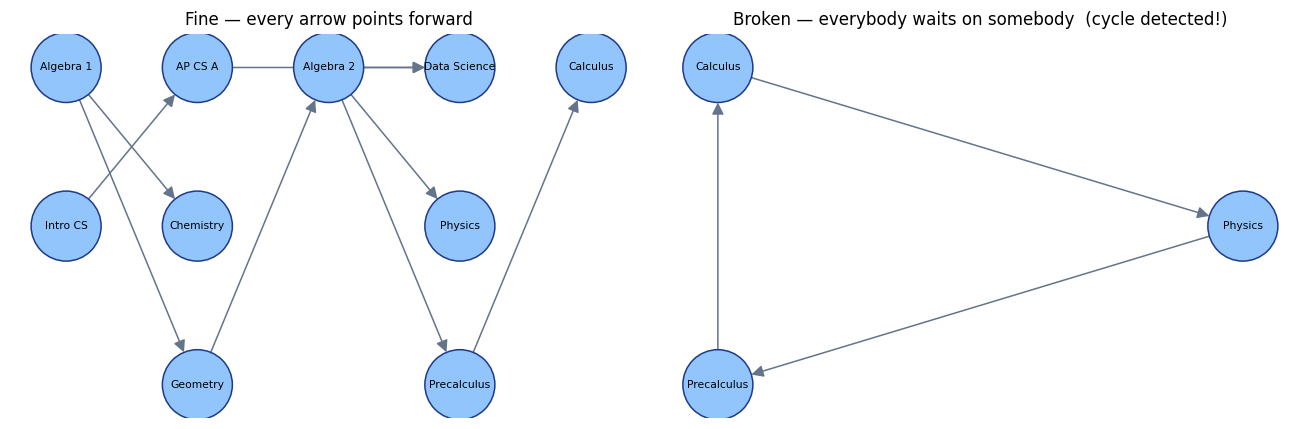

Can we finish the broken catalog? False


In [ ]:
BROKEN = build_graph(
    ["Physics", "Calculus", "Precalculus"],
    [("Physics", "Calculus"), ("Calculus", "Precalculus"), ("Precalculus", "Physics")],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
draw_courses(GRAPH, title="Fine — every arrow points forward", ax=axes[0])
draw_courses(BROKEN, title="Broken — everybody waits on somebody", ax=axes[1])
plt.tight_layout()
plt.show()

print("Can we finish the broken catalog?", can_finish(3, [[0, 1], [1, 2], [2, 0]]))

In the picture on the right, every course is waiting on another one. Walk in
anywhere and you eventually step back onto your own trail — `Physics → Calculus →
Precalculus → Physics` — and the first 🟠 you bump into ends it. A cycle in a
prerequisite graph is a real thing that happens to real registrars, and this is
how software catches it.

---
## Part 6 — Course Schedule II: *in what order?*

Same algorithm — you barely have to touch it. Instead of returning `True` when a
course finishes, **write the course down** at that moment.

But remember the warning from Part 4: a course is finished only *after*
everything it unlocks is finished, so it gets written down **after** them. The
list comes out backwards.

### ✏️ Task 4 — `find_order`

Add an `order` list. Append `c` right where you set `state[c] = 2`. Then
**reverse it** before returning. Return `[]` if graduation is impossible.

In [ ]:
def find_order(n, prerequisites):
    """LeetCode 210. Return a valid course order, or [] if impossible."""
    graph = {i: [] for i in range(n)}
    for course, prereq in prerequisites:
        graph[prereq].append(course)

    state = [0] * n
    order = []

    def dfs(c):
        # YOUR CODE HERE
        # Start from your can_finish dfs. Add ONE line: append c to `order`
        # at the moment you mark it finished.
        if state[c] == 1:
          return False
        if state[c] == 2:
          return True
        state[c] = 1
        for v in graph[c]:
          if not dfs(v):
            return False
        order.append(c)
        state[c] = 2
        return True
    """
    if state [c] == 1:
          return False
        if state [c] == 2:
          return True
        state[c] = 1 # untouched becomes on trail, start
        for v in graph[c]:
          if not dfs(v): # if not reach end
            return False
        state[c] = 2 #dfs did not return false, ended
        return True
        raise NotImplementedError()
    """
    for c in range(n):
        if state[c] == 0 and not dfs(c):
            return []
    order.reverse()
    # YOUR CODE HERE
    # `order` is backwards (finished-last). Fix that, then return it.
    return order

Careful — there is usually **more than one correct answer**. `[0, 1, 2, 3]` and `[0, 2, 1, 3]` can both be valid. So we do not compare against one fixed list; we write a checker that verifies the rules were obeyed.

In [ ]:
def is_valid_order(n, prerequisites, order):
    """True if `order` contains all n courses and never puts a course before its prereq."""
    if sorted(order) != list(range(n)):
        return False
    position = {course: i for i, course in enumerate(order)}
    return all(position[prereq] < position[course] for course, prereq in prerequisites)


# ✅ Check — Task 4
print(find_order(2, [[1, 0]]))
assert find_order(2, [[1, 0]]) == [0, 1]
assert find_order(2, [[1, 0], [0, 1]]) == []
assert is_valid_order(4, [[1, 0], [2, 0], [3, 1], [3, 2]],
                      find_order(4, [[1, 0], [2, 0], [3, 1], [3, 2]]))
assert is_valid_order(6, [[2, 5], [0, 5], [3, 2], [1, 3], [1, 4]],
                      find_order(6, [[2, 5], [0, 5], [3, 2], [1, 3], [1, 4]]))
assert find_order(3, [[0, 1], [1, 2], [2, 0]]) == []
print("PASSED ✅  You solved LeetCode 210. Both problems, one algorithm.")

[0, 1]
PASSED ✅  You solved LeetCode 210. Both problems, one algorithm.


---
## Part 7 — Watch it run 🎬

You have written the algorithm. Now see it. Each panel below is the moment one
course **finishes** and gets written down:

- 🟠 **orange** = on the trail right now (started, not finished)
- 🔵 **blue** = not visited yet
- ⬜ **grey** = finished and written down

Watch the orange trail grow deep down one branch, then unwind as courses finish
from the bottom up. That unwinding is why the list comes out backwards.

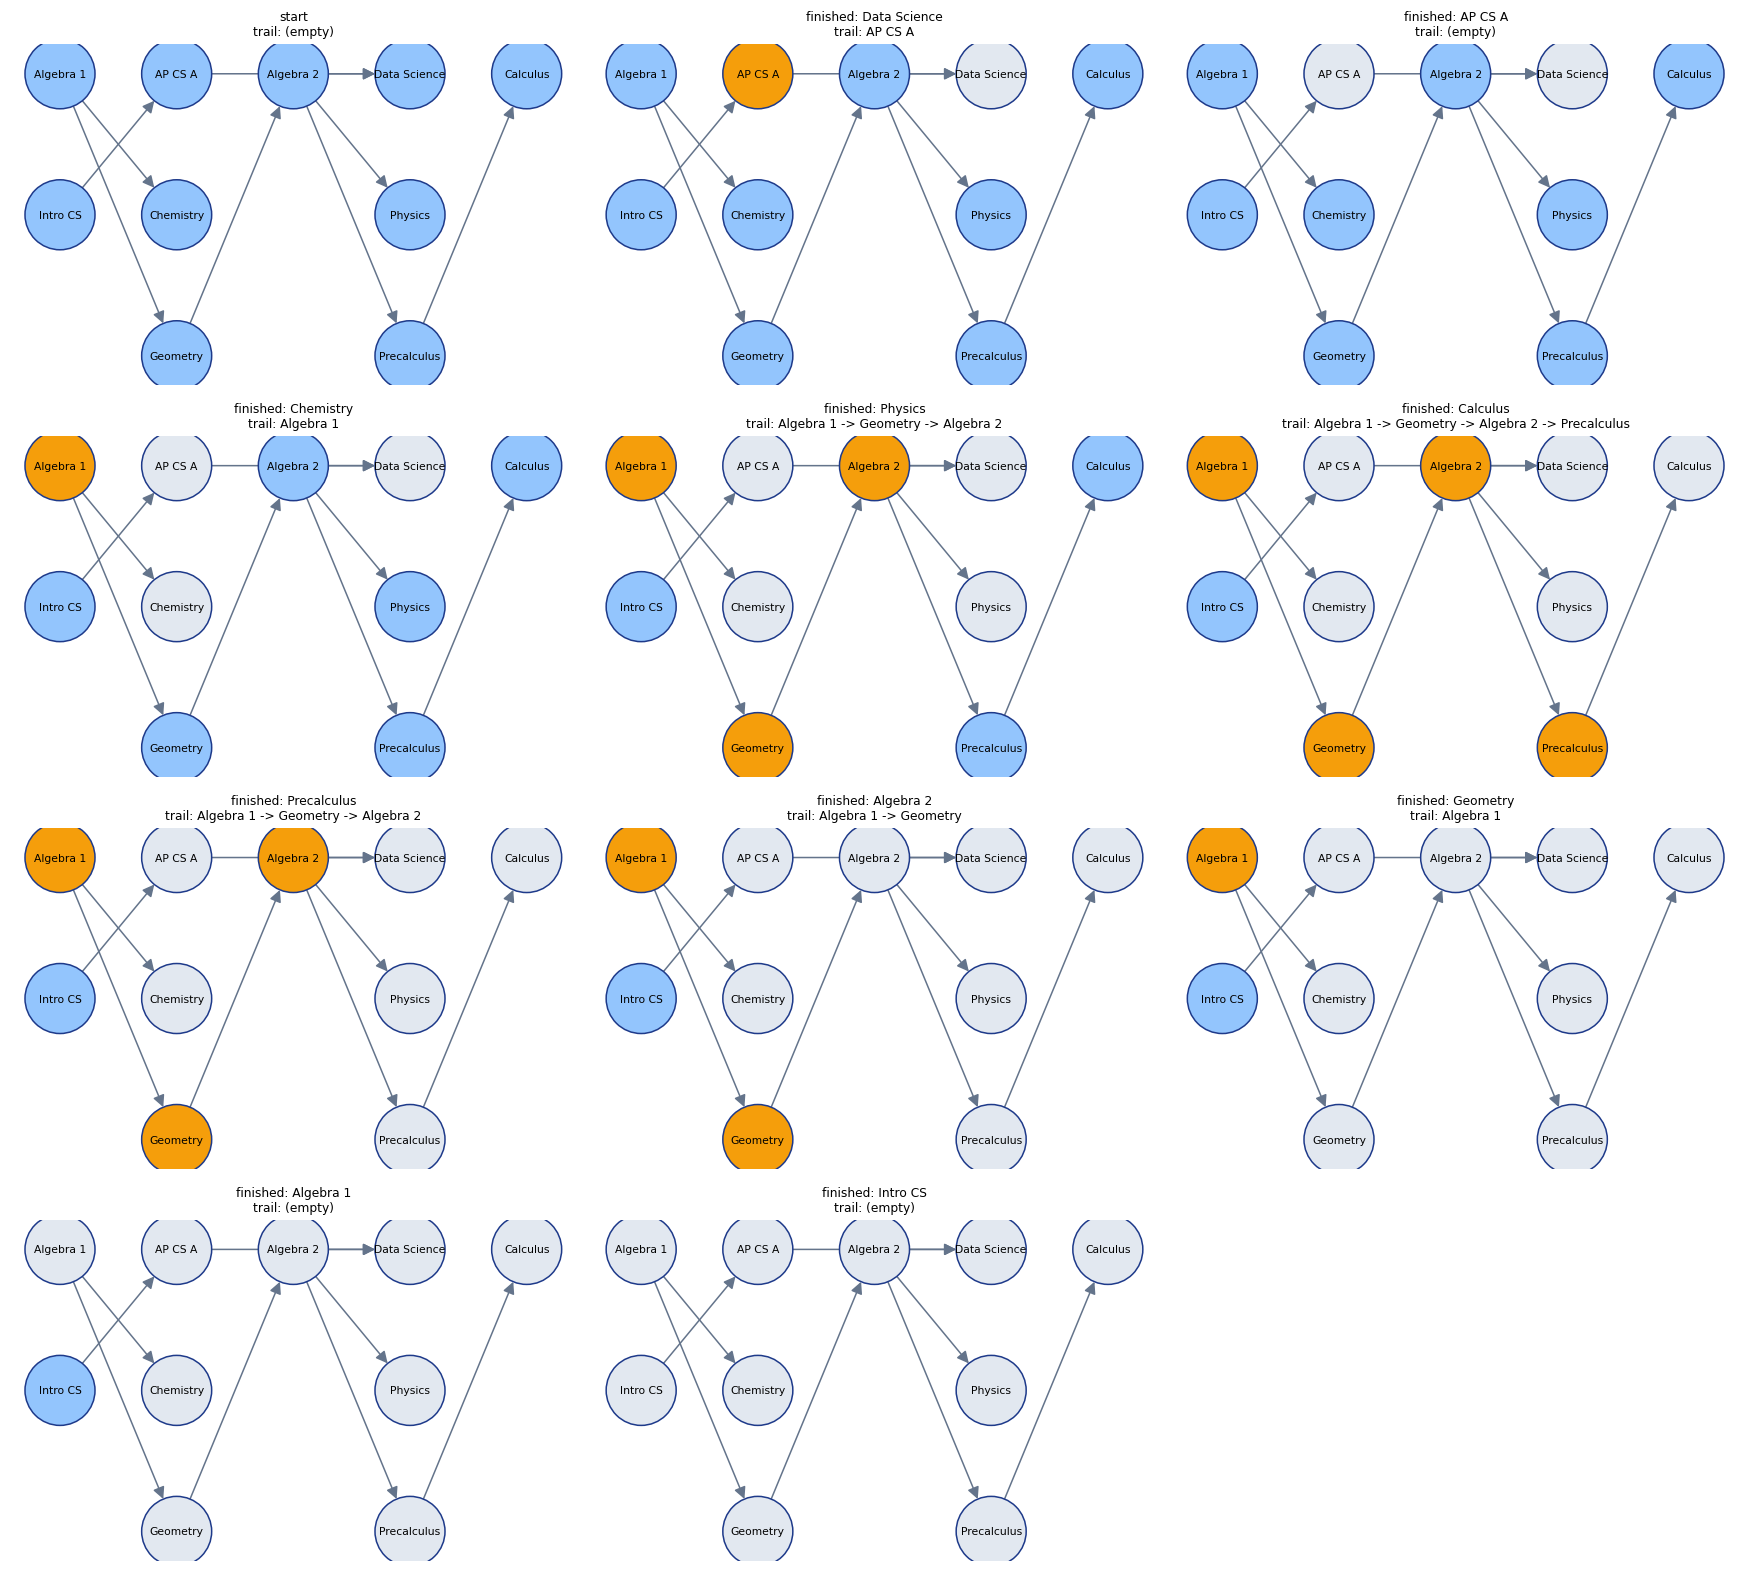

Written down in this order (finish order):
    Data Science -> AP CS A -> Chemistry -> Physics -> Calculus -> Precalculus -> Algebra 2 -> Geometry -> Algebra 1 -> Intro CS

Reversed — the order you actually take them:
    Intro CS -> Algebra 1 -> Geometry -> Algebra 2 -> Precalculus -> Calculus -> Physics -> Chemistry -> AP CS A -> Data Science


In [ ]:
def visualize_dfs(graph):
    """Draw the DFS one finished course at a time."""
    state = {c: 0 for c in graph}
    order, trail, frames = [], [], []
    frames.append((dict(state), [], [], None))

    def dfs(u):
        state[u] = 1
        trail.append(u)
        for v in sorted(graph[u]):
            if state[v] == 0:
                dfs(v)
        state[u] = 2
        order.append(u)
        trail.pop()
        frames.append((dict(state), list(order), list(trail), u))

    for c in sorted(graph):
        if state[c] == 0:
            dfs(c)

    rows = (len(frames) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(16, 3.6 * rows))
    for ax, (st, done, tr, just) in zip(axes.flat, frames):
        cmap = {n: ("#e2e8f0" if st[n] == 2 else "#f59e0b" if st[n] == 1 else "#93c5fd")
                for n in graph}
        draw_courses(graph, title="", ax=ax, color_map=cmap)
        head = "start" if just is None else f"finished: {just}"
        ax.set_title(f"{head}\ntrail: {' -> '.join(tr) or '(empty)'}", fontsize=8)
    for ax in axes.flat[len(frames):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return order


post = visualize_dfs(GRAPH)
print("Written down in this order (finish order):")
print("   ", " -> ".join(post))
print("\nReversed — the order you actually take them:")
print("   ", " -> ".join(reversed(post)))

The grey courses always finish from the **bottom of a chain upward**:
`Calculus` is written down before `Precalculus`, which is written down before
`Algebra 2`. Reversing fixes it — and that reversal *is* the proof the algorithm
is correct. A course can only be written down after every course it unlocks,
so once flipped, it lands before all of them.

---
## Part 8 — From a list to a real semester plan

A list like `[Algebra 1, Intro CS, Geometry, ...]` says take them one at a time.
But you take **several courses per semester**. So instead of an order, ask each
course a question:

> **How early could I possibly take this?**

- No prerequisites at all → semester **0**
- Otherwise → **1 + (the latest semester any of my prerequisites lands in)**

That definition is recursive: to answer for `Calculus` you first need the answer
for `Precalculus`. Perfect job for DFS.

One catch — `Data Science` gets asked about twice (once via `AP CS A`, once via
`Algebra 2`). Recomputing it every time would be wasteful, so store each answer
the first time you work it out and reuse it. That trick is called
**memoization**, and it is the single most useful thing you can add to a
recursive function.

### ✏️ Task 5 — `semester_plan`

You will need each course's **prerequisites**, but `GRAPH` stores the arrows the
other way round. Flip it first, then recurse.

In [ ]:
def build_prereq_map(graph):
    """Flip the graph: {course: [its prerequisites]}."""
    prereqs = {c: [] for c in graph}
    for src_course, unlocked_courses in graph.items():
        for unlocked_course in unlocked_courses:
            prereqs[unlocked_course].append(src_course)
    return prereqs


def semester_plan(graph):
    """Return a list of lists: the courses you can take in each semester."""
    prereqs = build_prereq_map(graph)
    memo = {}

    def earliest(c):
        """Earliest semester `c` could be taken."""
        # YOUR CODE HERE
        # no prerequisites          -> 0
        # otherwise                 -> 1 + the LATEST semester any prereq lands in
        # store the answer in `memo` so each course is worked out only once
        if c not in memo:
          if not prereqs[c]:
            memo[c] = 0
          else:
            memo[c] = 1 + max(earliest(prereq) for prereq in prereqs[c]) #add one for each
        return memo[c]

    plan = []
    for c in sorted(graph):
        s = earliest(c)
        while len(plan) <= s:
            plan.append([])
        plan[s].append(c)
    return plan


PLAN = semester_plan(GRAPH)
for i, sem in enumerate(PLAN):
    print(f"Semester {i}: {', '.join(sem)}")

Semester 0: Algebra 1, Intro CS
Semester 1: AP CS A, Chemistry, Geometry
Semester 2: Algebra 2
Semester 3: Data Science, Physics, Precalculus
Semester 4: Calculus


In [ ]:
# ✅ Check — Task 5
assert sum(len(s) for s in PLAN) == len(COURSES), "every course appears exactly once"
assert set(PLAN[0]) == {"Algebra 1", "Intro CS"}, "semester 0 = no prerequisites"
placed = {c: i for i, sem in enumerate(PLAN) for c in sem}
assert all(placed[prereq] < placed[course] for course, prereq in CATALOG), "a prereq must land in an earlier semester"
assert len(PLAN) == 5, "this catalog needs 5 semesters"
print(f"PASSED ✅  Minimum time to graduate: {len(PLAN)} semesters.")

PASSED ✅  Minimum time to graduate: 5 semesters.


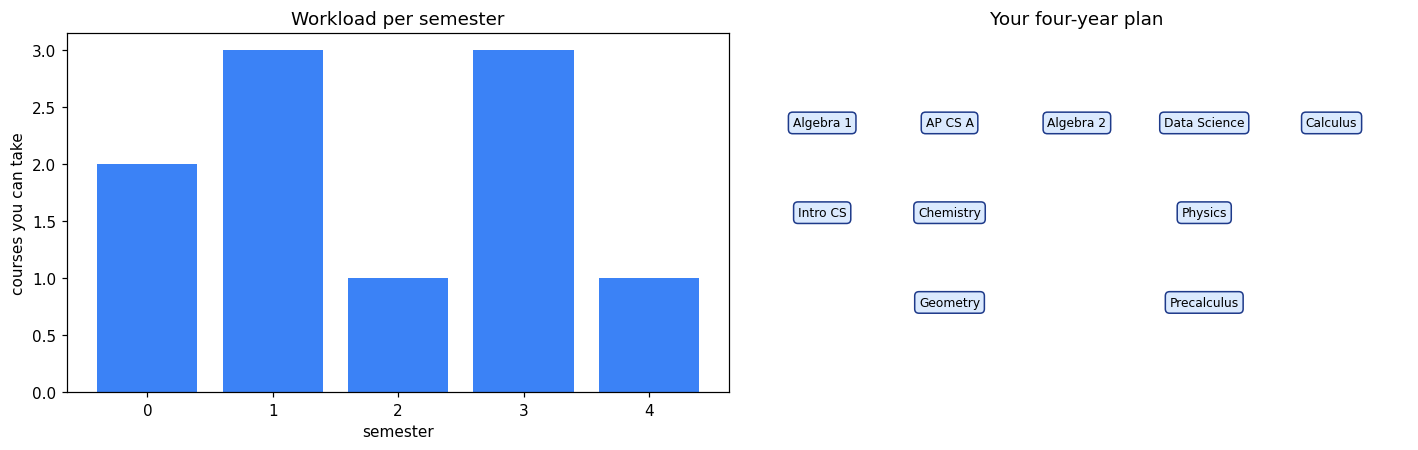

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.bar(range(len(PLAN)), [len(s) for s in PLAN], color="#3b82f6")
ax1.set_xlabel("semester")
ax1.set_ylabel("courses you can take")
ax1.set_title("Workload per semester")
ax1.set_xticks(range(len(PLAN)))

for i, sem in enumerate(PLAN):
    for j, c in enumerate(sem):
        ax2.text(i, -j, c, ha="center", va="center", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.35", fc="#dbeafe", ec="#1e3a8a"))
ax2.set_xlim(-0.6, len(PLAN) - 0.4)
ax2.set_ylim(-max(len(s) for s in PLAN), 1)
ax2.set_title("Your four-year plan")
ax2.axis("off")
plt.tight_layout()
plt.show()

Look at the bar chart. Semester 0 is crowded and later semesters are thin — the graph has a long skinny tail (`Algebra 2 → Precalculus → Calculus`). That chain is called the **critical path**, and no amount of hard work shortens it. It is the same math that project managers use to schedule buildings and that build systems use to compile your code in parallel.

---
## Part 9 — Make it yours 🏆

Pick **one** (or more, if you are flying):

**A. Your actual schedule.** Rewrite `CATALOG` with the real courses you want to take before you graduate, including electives and their real prerequisites. Run `semester_plan` and `draw_courses` on it. How many semesters do you need? Does the picture match the plan in your head?

**B. Name the deadlock.** Add one rule to `CATALOG` that creates a cycle. Show that `draw_courses` reports it and that `can_finish` returns `False`. Then make the algorithm *print the actual loop*. (*Hint: keep a `trail` list alongside `state`, exactly like the visualization does. When you hit a course that is 🟠, that course is already somewhere in `trail` — everything from there to the end of the trail is your cycle.*)

**C. Change the tie-break.** When a course unlocks several others, `find_order` explores them in whatever order they sit in the list. Sort `graph[c]` before the loop and re-run. Does the final order change? Is it still valid? Why can two different answers both be correct?

**D. Break the recursion.** Generate a chain of 50,000 courses (`[[i+1, i] for i in range(49999)]`) and call `find_order` on it. It will crash — read the error. Then rewrite `dfs` as a loop with an explicit stack so it does not. This is the one real weakness of the recursive version, and the reason production code often uses the queue-based approach instead.

---
## What you learned today

| idea | where you used it |
|---|---|
| adjacency list | `build_graph` |
| recursion / depth-first search | `unlocks_all` |
| three states (untouched / on the trail / finished) | `can_finish` |
| post-order + reverse = topological sort | `find_order` |
| memoization | `semester_plan` |
| cycle detection | LeetCode 207 + 210 |

The algorithm you wrote runs in **O(nodes + edges)** time — it touches every course once and every rule once. That is why it still works on a catalog with a million courses (as long as you do not blow the recursion limit — see Bonus D).

**The one sentence to remember:** a course is safe to write down only once
everything it unlocks is already written down — so build the list backwards, then
flip it.

And you have seen it three ways: as a picture, as a hand trace on paper, and as a
dozen lines of Python. That is the whole job.

typesetting machine -> []
caldwell linotype factory -> ['typesetting machine']
illustrator desk -> []
graphic workshop -> ['illustrator desk']
cheaper paper   -> []
marcal paper plant -> ['cheaper paper']
buy influence points queens -> []
republican committee -> ['buy influence points queens']
traits queens   -> []
saint elizabeth college -> ['traits queens']
canteen kitchen -> []
silver inn restaurant -> ['canteen kitchen']
telegraphing station -> []
radio tower     -> ['telegraphing station']
cartographer desk -> []
cartography association -> ['cartographer desk']
ads             -> []
ad agency       -> ['ads', 'hudson heights']
lawyer desk     -> []
courthouse      -> ['lawyer desk', 'bronx zoo']
elevator        -> []
throgs neck factory -> ['elevator', 'pelham']
mayor           -> []
empire state building -> ['mayor', 'central park']
printer page module -> []
industrial city harbor -> ['printer page module']
utility         -> []
coney island    -> ['utility']
mafia           -> [

<Axes: title={'center': 'Fine — every arrow points forward'}>

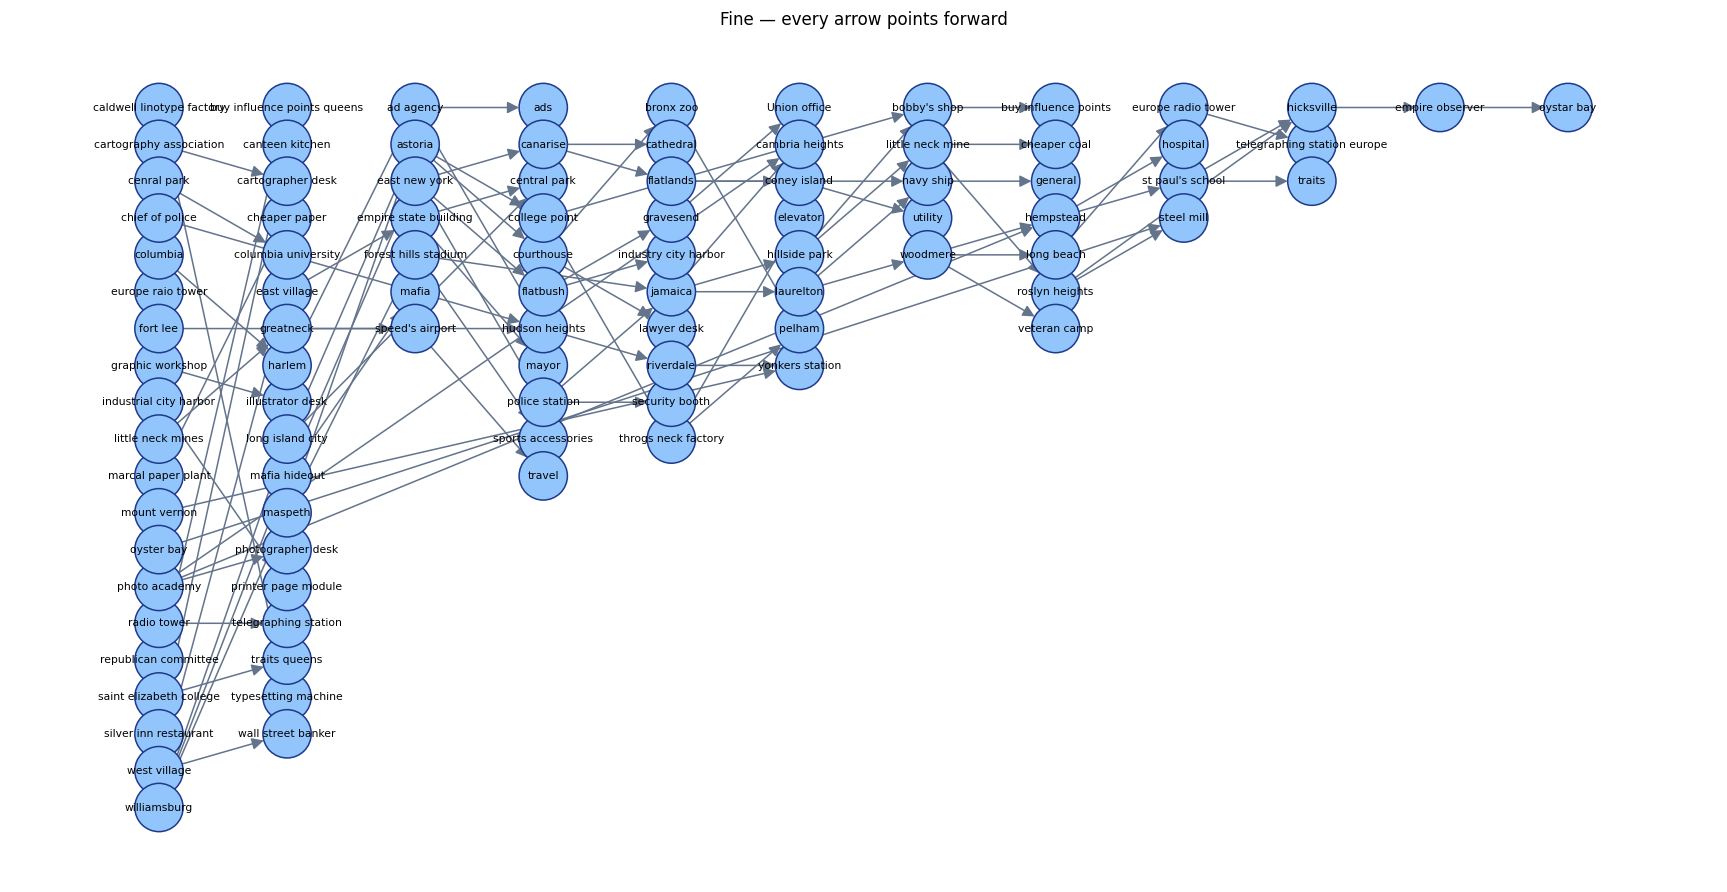

In [26]:
CATALOG_newstower = [
    ("typesetting machine",      "caldwell linotype factory"),
    ("illustrator desk",     "graphic workshop"),
    ("cheaper paper",   "marcal paper plant"),
    ("buy influence points queens",      "republican committee"),
    ("traits queens",       "saint elizabeth college"),
    ("canteen kitchen",     "silver inn restaurant"),
    ("telegraphing station",       "radio tower"),
    ("cartographer desk",  "cartography association"),
    ("ads",  "ad agency"),
    ("lawyer desk","courthouse"),
    ("elevator","throgs neck factory"),
    ("mayor","empire state building"),
    ("printer page module","industrial city harbor"),
    ("utility","coney island"),
    ("mafia","mafia hideout"),
    ("sports accessories","forest hills stadium"),
    ("security booth","police station"),
    ("general","navy ship"),
    ("buy influence points","bobby's shop"),
    ("cheaper coal","little neck mine"),
    ("photographer desk","photo academy"),
    ("telegraphing station europe","europe radio tower"),
    ("traits","st paul's school"),
    ("travel","speed's airport"),
    ("wall street banker","west village"),
    ("east village","west village"),
    ("empire state building","east village"),
    ("central park","empire state building"),
    ("central park","long island city"),
    ("columbia university","cenral park"),
    ("harlem","columbia"),
    ("ad agency","harlem"),
    ("hudson heights","ad agency"),
    ("hudson heights","fort lee"),
    ("hudson heights","chief of police"),
    ("riverdale","hudson heights"),
    ("yonkers station","riverdale"),
    ("yonkers station","mount vernon"),
    ("pelham","bronx zoo"),
    ("pelham","throgs neck factory"),
    ("throgs neck factory","college point"),
    ("bronx zoo","courthouse"),
    ("courthouse","astoria"),
    ("astoria","long island city"),
    ("astoria","maspeth"),
    ("long island city","williamsburg"),
    ("maspeth","williamsburg"),
    ("mafia hideout","williamsburg"),
    ("forest hills stadium","maspeth"),
    ("college point","astoria"),
    ("bobby's shop","college point"),
    ("jamaica","forest hills stadium"),
    ("hillside park","jamaica"),
    ("east new york","mafia hideout"),
    ("flatbush","east new york"),
    ("industry city harbor","flatbush"),
    ("gravesend","flatbush"),
    ("Union office","gravesend"),
    ("canarise","east new york"),
    ("cathedral","canarise"),
    ("flatlands","canarise"),
    ("coney island","flatlands"),
    ("navy ship","flatlands"),
    ("police station","east new york"),
    ("jamaica","police station"),
    ("bobby's shop","hillside park"),
    ("laurelton","jamaica"),
    ("cambria heights","jamaica"),
    ("little neck mine","hillside park"),
    ("navy ship","laurelton"),
    ("greatneck","little neck mines"),
    ("speed's airport","greatneck"),
    ("roslyn heights","little neck mine"),
    ("steel mill","roslyn heights"),
    ("steel mill","oyster bay"),
    ("oystar bay","empire observer"),
    ("hicksville","roslyn heights"),
    ("empire observer","hicksville"),
    ("cambria heights","photo academy"),
    ("hempstead","photo academy"),
    ("hempstead","woodmere"),
    ("veteran camp","woodmere"),
    ("woodmere","laurelton"),
    ("long beach","woodmere"),
    ("europe radio tower","long beach"),
    ("hospital","hempstead"),
    ("st paul's school","hempstead"),
    ("hicksville","st paul's school"),]
"""("greenville","bayonne"),
    ("loew's jersey theater","greenville"),
    ("loew's jersey theater","hoboken"),
    ("hoboken","west new york"),
    ("north bergn",""),
    ("",""),
    ("",""),
    ("",""),
    ("",""),
    ("",""),
    ("",""),
"""

unlocks = ["typesetting machine","caldwell linotype factory",
           "illustrator desk","graphic workshop","cheaper paper",
           "marcal paper plant","buy influence points queens","republican committee",
           "traits queens","saint elizabeth college","canteen kitchen","silver inn restaurant",
           "telegraphing station","radio tower","cartographer desk","cartography association","ads","ad agency",
           "lawyer desk","courthouse","elevator","throgs neck factory","mayor","empire state building","printer page module",
           "industrial city harbor","utility","coney island","mafia","mafia hideout","sports accessories","forest hills stadium",
           "security booth","police station","general","navy ship","buy influence points","bobby's shop","cheaper coal","little neck mine",
           "photographer desk","photo academy","telegraphing station europe","europe raio tower","traits","st paul's school","travel",
           "speed's airport","wall street banker","west village","east village","central park","long island city","columbia university",
           "cenral park","harlem","columbia","hudson heights","fort lee","chief of police","riverdale","yonkers station","mount vernon",
           "pelham","bronx zoo","college point","astoria","maspeth","williamsburg","jamaica","hillside park","east new york","flatbush",
           "industry city harbor","gravesend","Union office","canarise","cathedral","flatlands","laurelton","cambria heights","greatneck",
           "little neck mines","roslyn heights","steel mill","oyster bay","oystar bay","empire observer","hicksville","hempstead","woodmere",
           "veteran camp","long beach","europe radio tower","hospital"]

GRAPH_newstower = build_graph(unlocks, CATALOG_newstower)



for course, unlocks in GRAPH_newstower.items():
    print(f"{course:15s} -> {unlocks}")
fig, axes = plt.subplots(1, 1, figsize=(20, 10)) # Increased figsize
draw_courses(GRAPH_newstower, title="Fine — every arrow points forward", ax=axes)

### ✏️ Task: Find prerequisites for a Newstower item

In [27]:
def build_prereq_map_newstower(graph):
    """Flips the graph: {course: [its prerequisites]}."""
    prereqs = {c: [] for c in graph}
    for src_course, unlocked_courses in graph.items():
        for unlocked_course in unlocked_courses:
            # Only add if the unlocked_course is a valid key in prereqs
            # This handles cases where 'unlocks' contains items not in 'CATALOG_newstower' as prerequisites
            if unlocked_course in prereqs:
                prereqs[unlocked_course].append(src_course)
    return prereqs

def find_all_prerequisites(graph, target_item):
    """Finds all items that must be unlocked before the target_item."""
    prereq_map = build_prereq_map_newstower(graph)

    required_prereqs = set()

    def walk_prereqs(item):
        # Base case: if no prerequisites, stop
        if item not in prereq_map or not prereq_map[item]:
            return

        for prereq in prereq_map[item]:
            if prereq not in required_prereqs:
                required_prereqs.add(prereq)
                walk_prereqs(prereq)

    walk_prereqs(target_item)
    return sorted(list(required_prereqs))

# Example usage:
target = "lawyer desk"
prereqs_for_target = find_all_prerequisites(GRAPH_newstower, target)
print(f"To unlock '{target}', you need to unlock these first:\n{prereqs_for_target}")

target_2 = "long island city"
prereqs_for_target_2 = find_all_prerequisites(GRAPH_newstower, target_2)
print(f"\nTo unlock '{target_2}', you need to unlock these first:\n{prereqs_for_target_2}")

target_3 = "telegraphing station europe"
prereqs_for_target_3 = find_all_prerequisites(GRAPH_newstower, target_3)
print(f"\nTo unlock '{target_3}', you need to unlock these first:\n{prereqs_for_target_3}")


To unlock 'lawyer desk', you need to unlock these first:
['astoria', 'courthouse', 'long island city', 'maspeth', 'williamsburg']

To unlock 'long island city', you need to unlock these first:
['williamsburg']

To unlock 'telegraphing station europe', you need to unlock these first:
['east new york', 'europe radio tower', 'forest hills stadium', 'jamaica', 'laurelton', 'long beach', 'mafia hideout', 'maspeth', 'police station', 'williamsburg', 'woodmere']
